<a href="https://colab.research.google.com/github/aayushmanz/Python-For-Data-Science/blob/main/Pandas%20in%20Python/Practice%20in%20pandas/Practice_6_Dirty_cafe_sales.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [217]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
df = pd.read_csv('/workspaces/Python-For-Data-Science/Database from Kaggle/dirty_cafe_sales.csv')


In [218]:
df.shape # the size of the index are 10000 followed by 8 columns

(10000, 8)

In [219]:
df['Item'].hasnans # ok in our dataset there are several NaN values in our items columns

True

In [220]:
df[df['Item'].isnull()].count() # now we counted all values which are null in database.

Transaction ID      333
Item                  0
Quantity            330
Price Per Unit      326
Total Spent         329
Payment Method      251
Location            229
Transaction Date    327
dtype: int64

In [221]:
df[df['Item'].notnull()].count()


Transaction ID      9667
Item                9667
Quantity            9532
Price Per Unit      9495
Total Spent         9498
Payment Method      7170
Location            6506
Transaction Date    9514
dtype: int64

In [222]:
df.shape # sorry woh experiment toh khoob mare but fr socha sab NaN uda deta hu kya hi hoga

(10000, 8)

In [223]:
df

,Transaction ID,Item,Quantity,Price Per Unit,Total Spent,Payment Method,Location,Transaction Date
0,TXN_1961373,Coffee,2,2.0,4.0,Credit Card,Takeaway,2023-09-08
1,TXN_4977031,Cake,4,3.0,12.0,Cash,In-store,2023-05-16
2,TXN_4271903,Cookie,4,1.0,ERROR,Credit Card,In-store,2023-07-19
3,TXN_7034554,Salad,2,5.0,10.0,UNKNOWN,UNKNOWN,2023-04-27
4,TXN_3160411,Coffee,2,2.0,4.0,Digital Wallet,In-store,2023-06-11
...,...,...,...,...,...,...,...,...
9995,TXN_7672686,Coffee,2,2.0,4.0,NaN,UNKNOWN,2023-08-30
9996,TXN_9659401,NaN,3,NaN,3.0,Digital Wallet,NaN,2023-06-02
9997,TXN_5255387,Coffee,4,2.0,8.0,Digital Wallet,NaN,2023-03-02
9998,TXN_7695629,Cookie,3,NaN,3.0,Digital Wallet,NaN,2023-12-02


In [224]:
bringmeback = {
    1.0 : "Cookie",
    2.0 : "Coffee",
    3.0 : "Cake",
    4.0 : "Smoothie",
    5.0 : "Salad"
}
df['Price Per Unit'] = df['Price Per Unit'].replace(['ERROR', 'UNKNOWN', 'NaN'], np.nan)
df['Price Per Unit'] = pd.to_numeric(df['Price Per Unit'])
df['Item'] = df['Item'].replace(['ERROR', 'UNKNOWN'], np.nan)
df['Item'] = df['Item'].fillna(df['Price Per Unit'].map(bringmeback))
df.dropna(subset=['Item'], inplace=True)

df.shape # so this is our cleaned data

(9836, 8)

In [225]:
df.head(50)

,Transaction ID,Item,Quantity,Price Per Unit,Total Spent,Payment Method,Location,Transaction Date
0,TXN_1961373,Coffee,2,2.0,4.0,Credit Card,Takeaway,2023-09-08
1,TXN_4977031,Cake,4,3.0,12.0,Cash,In-store,2023-05-16
2,TXN_4271903,Cookie,4,1.0,ERROR,Credit Card,In-store,2023-07-19
3,TXN_7034554,Salad,2,5.0,10.0,UNKNOWN,UNKNOWN,2023-04-27
4,TXN_3160411,Coffee,2,2.0,4.0,Digital Wallet,In-store,2023-06-11
5,TXN_2602893,Smoothie,5,4.0,20.0,Credit Card,NaN,2023-03-31
6,TXN_4433211,Cake,3,3.0,9.0,ERROR,Takeaway,2023-10-06
7,TXN_6699534,Sandwich,4,4.0,16.0,Cash,UNKNOWN,2023-10-28
8,TXN_4717867,Cake,5,3.0,15.0,NaN,Takeaway,2023-07-28
9,TXN_2064365,Sandwich,5,4.0,20.0,NaN,In-store,2023-12-31


In [226]:
# lets check that how many number of NaN and ERROR values in Quantity
df[df['Quantity']=='ERROR']

,Transaction ID,Item,Quantity,Price Per Unit,Total Spent,Payment Method,Location,Transaction Date
20,TXN_3522028,Smoothie,ERROR,4.0,20.0,Cash,In-store,2023-04-04
55,TXN_5522862,Cookie,ERROR,1.0,2.0,Credit Card,Takeaway,2023-03-19
117,TXN_2148617,Juice,ERROR,3.0,9.0,Digital Wallet,UNKNOWN,2023-01-10
177,TXN_1896955,Salad,ERROR,5.0,25.0,NaN,In-store,2023-09-23
178,TXN_5075974,Smoothie,ERROR,4.0,16.0,Digital Wallet,NaN,2023-04-11
...,...,...,...,...,...,...,...,...
9832,TXN_3325234,Tea,ERROR,1.5,1.5,ERROR,In-store,2023-08-26
9846,TXN_7621213,Coffee,ERROR,2.0,6.0,NaN,In-store,2023-03-07
9911,TXN_2464054,Coffee,ERROR,2.0,10.0,NaN,Takeaway,2023-08-18
9935,TXN_9778251,Tea,ERROR,1.5,6.0,NaN,Takeaway,2023-11-09


In [227]:
# now its time to calculate and resolve the issues of these three numerical columns

# we converted all error and unknown values into NaN
df['Quantity'] = df['Quantity'].replace(['ERROR', 'UNKNOWN'], np.nan) 
df['Total Spent'] = df['Total Spent'].replace(['ERROR', 'UNKNOWN'], np.nan)
df['Price Per Unit'] = df['Price Per Unit'].replace(['ERROR', 'UNKNOWN'], np.nan)


# Then we also convert all values into numeric for solutions
mycols = ['Total Spent','Quantity']
for i in mycols:
  df[i] = pd.to_numeric(df[i], errors='coerce')



df['Quantity'] = df['Quantity'].fillna(df['Total Spent'] / df['Price Per Unit'])
df['Price Per Unit'] = df['Price Per Unit'].fillna(df['Total Spent'] / df['Quantity'])
df['Total Spent'] = df['Total Spent'].fillna(df['Price Per Unit'] * df['Quantity'])

df.dropna(subset='Price Per Unit', inplace=True) # i use it because there are some NaN values which are not deleted !
df.dropna(subset='Total Spent', inplace=True)

df.head(30)

,Transaction ID,Item,Quantity,Price Per Unit,Total Spent,Payment Method,Location,Transaction Date
0,TXN_1961373,Coffee,2.0,2.0,4.0,Credit Card,Takeaway,2023-09-08
1,TXN_4977031,Cake,4.0,3.0,12.0,Cash,In-store,2023-05-16
2,TXN_4271903,Cookie,4.0,1.0,4.0,Credit Card,In-store,2023-07-19
3,TXN_7034554,Salad,2.0,5.0,10.0,UNKNOWN,UNKNOWN,2023-04-27
4,TXN_3160411,Coffee,2.0,2.0,4.0,Digital Wallet,In-store,2023-06-11
5,TXN_2602893,Smoothie,5.0,4.0,20.0,Credit Card,NaN,2023-03-31
6,TXN_4433211,Cake,3.0,3.0,9.0,ERROR,Takeaway,2023-10-06
7,TXN_6699534,Sandwich,4.0,4.0,16.0,Cash,UNKNOWN,2023-10-28
8,TXN_4717867,Cake,5.0,3.0,15.0,NaN,Takeaway,2023-07-28
9,TXN_2064365,Sandwich,5.0,4.0,20.0,NaN,In-store,2023-12-31


In [228]:
# now its time to set the payment method colum
# there are lots of NaN values and some values are UNKNOWN or ERROR
# so I decided that i don't want to delete these NaN values so i m gonna replace them with cash
# because cash  is the most common way of transaction

<Axes: >

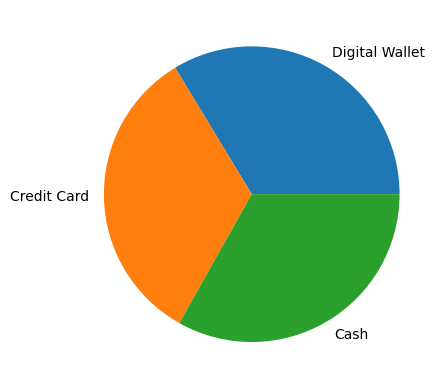

In [229]:
# we are just want to see that is cash is really common :

a = df['Payment Method'].replace(['UNKNOWN','ERROR'], np.nan)
a.value_counts().plot(kind='pie')

In [230]:
df['Payment Method'] = df['Payment Method'].replace(['UNKNOWN','ERROR'], np.nan)
df

,Transaction ID,Item,Quantity,Price Per Unit,Total Spent,Payment Method,Location,Transaction Date
0,TXN_1961373,Coffee,2.0,2.0,4.0,Credit Card,Takeaway,2023-09-08
1,TXN_4977031,Cake,4.0,3.0,12.0,Cash,In-store,2023-05-16
2,TXN_4271903,Cookie,4.0,1.0,4.0,Credit Card,In-store,2023-07-19
3,TXN_7034554,Salad,2.0,5.0,10.0,NaN,UNKNOWN,2023-04-27
4,TXN_3160411,Coffee,2.0,2.0,4.0,Digital Wallet,In-store,2023-06-11
...,...,...,...,...,...,...,...,...
9994,TXN_7851634,Smoothie,4.0,4.0,16.0,NaN,NaN,2023-01-08
9995,TXN_7672686,Coffee,2.0,2.0,4.0,NaN,UNKNOWN,2023-08-30
9997,TXN_5255387,Coffee,4.0,2.0,8.0,Digital Wallet,NaN,2023-03-02
9998,TXN_7695629,Cookie,3.0,1.0,3.0,Digital Wallet,NaN,2023-12-02


In [231]:
# in this code i randomly push those three possible transaction methods in our dataset.

mix = ['Credit Card','Cash','Digital Wallet']

df.loc[df['Payment Method'].isna(), 'Payment Method']= np.random.choice(mix, size=df['Payment Method'].isna().sum())
df.head(30)

,Transaction ID,Item,Quantity,Price Per Unit,Total Spent,Payment Method,Location,Transaction Date
0,TXN_1961373,Coffee,2.0,2.0,4.0,Credit Card,Takeaway,2023-09-08
1,TXN_4977031,Cake,4.0,3.0,12.0,Cash,In-store,2023-05-16
2,TXN_4271903,Cookie,4.0,1.0,4.0,Credit Card,In-store,2023-07-19
3,TXN_7034554,Salad,2.0,5.0,10.0,Digital Wallet,UNKNOWN,2023-04-27
4,TXN_3160411,Coffee,2.0,2.0,4.0,Digital Wallet,In-store,2023-06-11
5,TXN_2602893,Smoothie,5.0,4.0,20.0,Credit Card,NaN,2023-03-31
6,TXN_4433211,Cake,3.0,3.0,9.0,Cash,Takeaway,2023-10-06
7,TXN_6699534,Sandwich,4.0,4.0,16.0,Cash,UNKNOWN,2023-10-28
8,TXN_4717867,Cake,5.0,3.0,15.0,Credit Card,Takeaway,2023-07-28
9,TXN_2064365,Sandwich,5.0,4.0,20.0,Digital Wallet,In-store,2023-12-31


<Axes: >

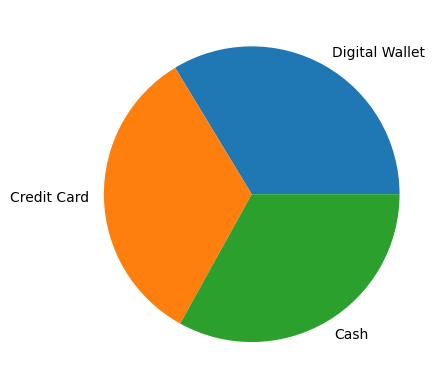

In [232]:
df['Payment Method'].value_counts().plot(kind='pie') # ok distribution is same as original.

In [233]:
df['Location'] = df['Location'].replace(['UNKNOWN','ERROR'], np.nan)

df

,Transaction ID,Item,Quantity,Price Per Unit,Total Spent,Payment Method,Location,Transaction Date
0,TXN_1961373,Coffee,2.0,2.0,4.0,Credit Card,Takeaway,2023-09-08
1,TXN_4977031,Cake,4.0,3.0,12.0,Cash,In-store,2023-05-16
2,TXN_4271903,Cookie,4.0,1.0,4.0,Credit Card,In-store,2023-07-19
3,TXN_7034554,Salad,2.0,5.0,10.0,Digital Wallet,NaN,2023-04-27
4,TXN_3160411,Coffee,2.0,2.0,4.0,Digital Wallet,In-store,2023-06-11
...,...,...,...,...,...,...,...,...
9994,TXN_7851634,Smoothie,4.0,4.0,16.0,Digital Wallet,NaN,2023-01-08
9995,TXN_7672686,Coffee,2.0,2.0,4.0,Credit Card,NaN,2023-08-30
9997,TXN_5255387,Coffee,4.0,2.0,8.0,Digital Wallet,NaN,2023-03-02
9998,TXN_7695629,Cookie,3.0,1.0,3.0,Digital Wallet,NaN,2023-12-02


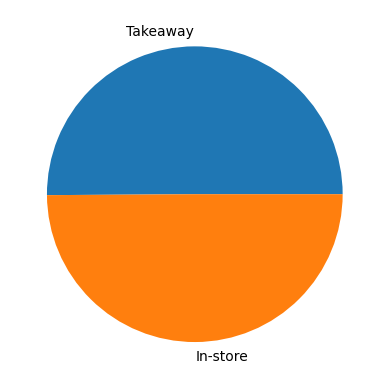

In [234]:
df['Location'].value_counts().plot(kind='pie')
plt.show()

In [235]:
mix = ['Takeaway','In-Store']
df.loc[df['Location'].isna(), 'Location']=np.random.choice(mix, size=df['Location'].isna().sum())

df.sample(30)

,Transaction ID,Item,Quantity,Price Per Unit,Total Spent,Payment Method,Location,Transaction Date
985,TXN_8692653,Juice,2.0,3.0,6.0,Cash,Takeaway,2023-11-01
6824,TXN_7763212,Sandwich,1.0,4.0,4.0,Credit Card,In-Store,2023-01-10
5458,TXN_6431215,Cake,1.0,3.0,3.0,Credit Card,In-Store,2023-08-27
6892,TXN_7735127,Smoothie,1.0,4.0,4.0,Digital Wallet,Takeaway,2023-02-22
2521,TXN_3033987,Cake,4.0,3.0,12.0,Cash,In-Store,2023-03-13
315,TXN_5754317,Coffee,2.0,2.0,4.0,Credit Card,Takeaway,2023-01-10
8701,TXN_8014289,Juice,5.0,3.0,15.0,Digital Wallet,In-store,2023-12-04
6737,TXN_6610487,Coffee,5.0,2.0,10.0,Digital Wallet,Takeaway,2023-09-18
2897,TXN_6533180,Coffee,5.0,2.0,10.0,Digital Wallet,Takeaway,2023-05-03
7964,TXN_9997263,Cookie,2.0,1.0,2.0,Credit Card,Takeaway,2023-03-05


In [236]:
# in this code i replace the whole null values with 2023-1-1 because my dadi aadhar card birth date is 1-jan.

df['Transaction Date']= df['Transaction Date'].replace(['UNKNOWN', 'ERROR'], np.nan)
s = pd.Series(['2023-1-1'])
df.loc[df['Transaction Date'].isna(), 'Transaction Date'] = pd.to_datetime(s, errors='coerce').iloc[0].strftime('%Y-%m-%d')
df['Transaction Date']=df['Transaction Date'].astype('datetime64[us]')
df.dropna(subset='Transaction Date', inplace=True) # for more clean data
df.sample(30)

,Transaction ID,Item,Quantity,Price Per Unit,Total Spent,Payment Method,Location,Transaction Date
4525,TXN_6363733,Tea,1.0,1.5,1.5,Credit Card,Takeaway,2023-10-25
4702,TXN_2659832,Sandwich,3.0,4.0,12.0,Credit Card,In-Store,2023-12-05
1750,TXN_6330369,Juice,1.0,3.0,3.0,Credit Card,Takeaway,2023-01-25
3957,TXN_7952916,Coffee,4.0,2.0,8.0,Digital Wallet,Takeaway,2023-12-10
9680,TXN_6992783,Tea,1.0,1.5,1.5,Digital Wallet,Takeaway,2023-01-29
934,TXN_7337979,Coffee,1.0,2.0,2.0,Digital Wallet,In-store,2023-05-27
8023,TXN_2616353,Smoothie,3.0,4.0,12.0,Cash,Takeaway,2023-06-24
2041,TXN_2564219,Salad,1.0,5.0,5.0,Digital Wallet,Takeaway,2023-07-18
3544,TXN_8139533,Smoothie,1.0,4.0,4.0,Cash,In-store,2023-09-21
5223,TXN_8212783,Salad,3.0,5.0,15.0,Credit Card,In-store,2023-03-30


In [237]:
df.info() # ok every thing is ok in dtype.

<class 'pandas.DataFrame'>
Index: 9784 entries, 0 to 9999
Data columns (total 8 columns):
 #   Column            Non-Null Count  Dtype         
---  ------            --------------  -----         
 0   Transaction ID    9784 non-null   str           
 1   Item              9784 non-null   str           
 2   Quantity          9784 non-null   float64       
 3   Price Per Unit    9784 non-null   float64       
 4   Total Spent       9784 non-null   float64       
 5   Payment Method    9784 non-null   str           
 6   Location          9784 non-null   str           
 7   Transaction Date  9784 non-null   datetime64[us]
dtypes: datetime64[us](1), float64(3), str(4)
memory usage: 687.9 KB


In [238]:
df.describe()

,Quantity,Price Per Unit,Total Spent,Transaction Date
count,9784.000000,9784.000000,9784.000000,9784
mean,3.025859,2.964789,8.983034,2023-06-23 15:00:08.830744
min,1.000000,1.000000,1.000000,2023-01-01 00:00:00
25%,2.000000,2.000000,4.000000,2023-03-19 18:00:00
50%,3.000000,3.000000,8.000000,2023-06-24 00:00:00
75%,4.000000,4.000000,12.000000,2023-09-27 00:00:00
max,5.000000,5.000000,25.000000,2023-12-31 00:00:00
std,1.421943,1.278428,6.017761,NaN


In [239]:
df.isnull().sum()

Transaction ID      0
Item                0
Quantity            0
Price Per Unit      0
Total Spent         0
Payment Method      0
Location            0
Transaction Date    0
dtype: int64